In [6]:
import sys
import joblib
from sklearn.preprocessing import LabelEncoder
import utils.ovo_svm as ovo_svm
sys.modules["ovo_svm"] = ovo_svm
from utils.ovo_svm import OvO_SVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
x = joblib.load("./features/x_char_features_hog.joblib")
y = joblib.load("./features/y_char_labels_hog.joblib")

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [9]:
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# model = OvO_SVM()
# model.fit(train_x, train_y, save_path="./models/from_scratch_SVM")

In [10]:
model = OvO_SVM.load("./models/from_scratch_SVM")

In [ ]:
# meta = joblib.load("./OvO_SVM/meta.joblib")
# meta["classes"] = {}

In [11]:
predictions = model.predict(test_x)

In [12]:
F1 = f1_score(test_y, predictions, average='weighted')
precision = precision_score(test_y, predictions, average='weighted')
recall = recall_score(test_y, predictions, average='weighted')
accuracy = accuracy_score(test_y, predictions)

print("F1 Score:", F1)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

F1 Score: 0.8663082315905903
Precision: 0.8706778336239219
Recall: 0.8643543138344313
Accuracy: 0.8643543138344313


In [13]:
conf_matrix = confusion_matrix(test_y, predictions)

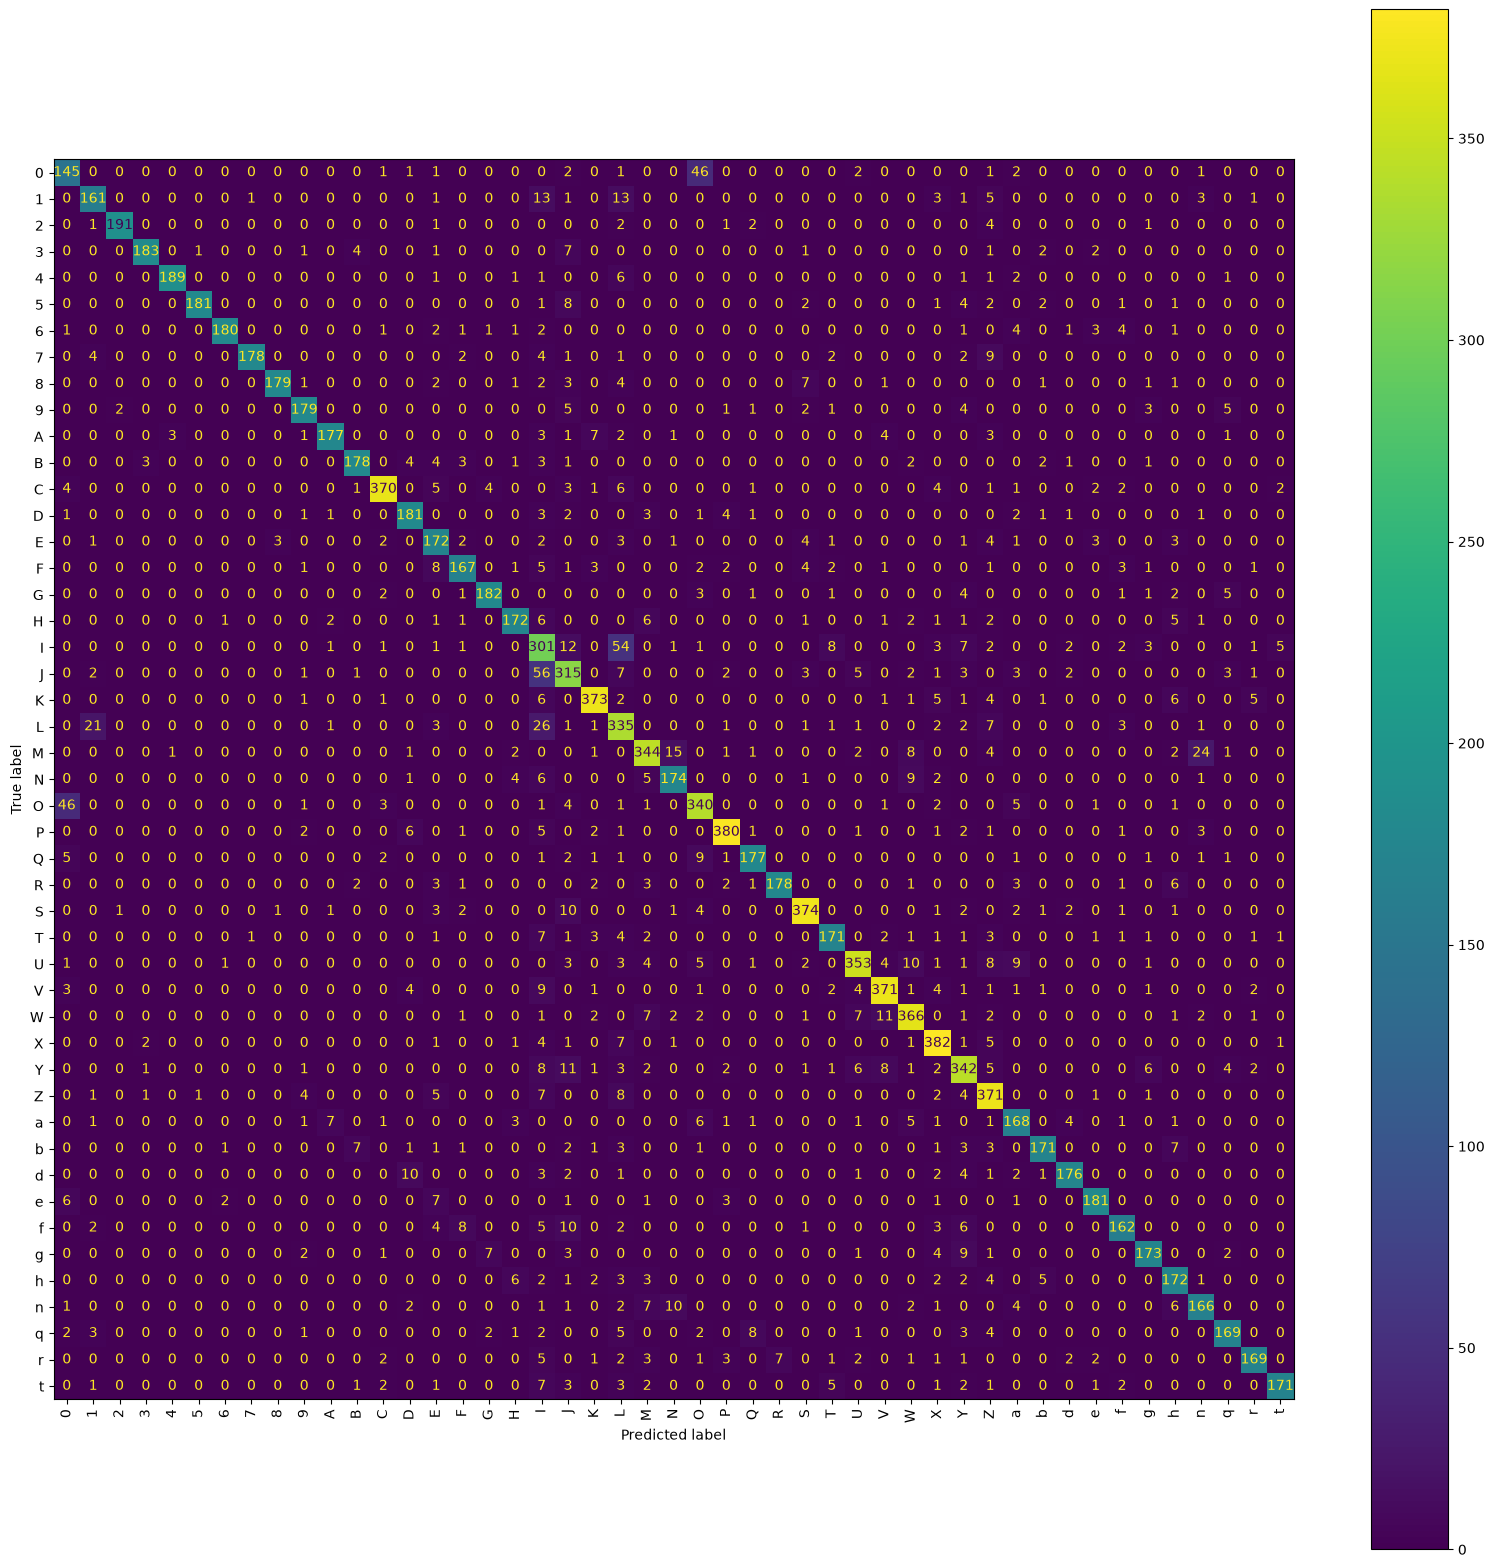

In [14]:
fig, ax = plt.subplots(figsize=(20, 20))

ConfusionMatrixDisplay.from_predictions(
    test_y,
    predictions,
    xticks_rotation='vertical',
    display_labels=le.classes_,
    ax=ax
)

plt.show()